# **Import Libraries**

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Load Data**

In [38]:
df=pd.read_csv('/content/drive/MyDrive/Projects/Customer Segmentation/Data/Final_merged_dataset.csv')

In [39]:
df.head()

,Unnamed: 0,customer_id,age,gender,payment_method,quantity,total_spent,purchase_count,store_count
0,0,C100004,61.0,Male,Credit Card,5,1500.40,1,200.0
1,1,C100005,34.0,Male,Cash,2,1200.34,1,270.0
2,2,C100006,44.0,Male,Credit Card,3,107.52,1,NaN
3,3,C100012,25.0,Male,Cash,5,26.15,1,270.0
4,4,C100019,21.0,Female,Credit Card,1,35.84,1,200.0


# **EDA**

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      99457 non-null  int64  
 1   customer_id     99457 non-null  object 
 2   age             99338 non-null  float64
 3   gender          99457 non-null  object 
 4   payment_method  99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   total_spent     99457 non-null  float64
 7   purchase_count  99457 non-null  int64  
 8   store_count     94466 non-null  float64
dtypes: float64(3), int64(3), object(3)
memory usage: 6.8+ MB


In [41]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [42]:
df.describe()

,age,quantity,total_spent,purchase_count,store_count
count,99338.000000,99457.000000,99457.000000,99457.0,94466.000000
mean,43.425859,3.003429,689.256321,1.0,208.818623
std,14.989400,1.413025,941.184567,0.0,42.534204
min,18.000000,1.000000,5.230000,1.0,140.000000
25%,30.000000,2.000000,45.450000,1.0,180.000000
50%,43.000000,3.000000,203.300000,1.0,220.000000
75%,56.000000,4.000000,1200.320000,1.0,230.000000
max,69.000000,5.000000,5250.000000,1.0,270.000000


## **Filling Missing Values**

In [43]:
# df['age'].fillna(df['age'].median(), inplace=True)
# df['store_count'].fillna(df['store_count'].median(), inplace=True)
df=df.fillna({
    'age': df['age'].median(),
    'store_count': df['store_count'].median()
})

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  object 
 1   age             99457 non-null  float64
 2   gender          99457 non-null  object 
 3   payment_method  99457 non-null  object 
 4   quantity        99457 non-null  int64  
 5   total_spent     99457 non-null  float64
 6   purchase_count  99457 non-null  int64  
 7   store_count     99457 non-null  float64
dtypes: float64(3), int64(2), object(3)
memory usage: 6.1+ MB


In [45]:
eda_col =df.drop(['customer_id', 'gender', 'payment_method'], axis=1)

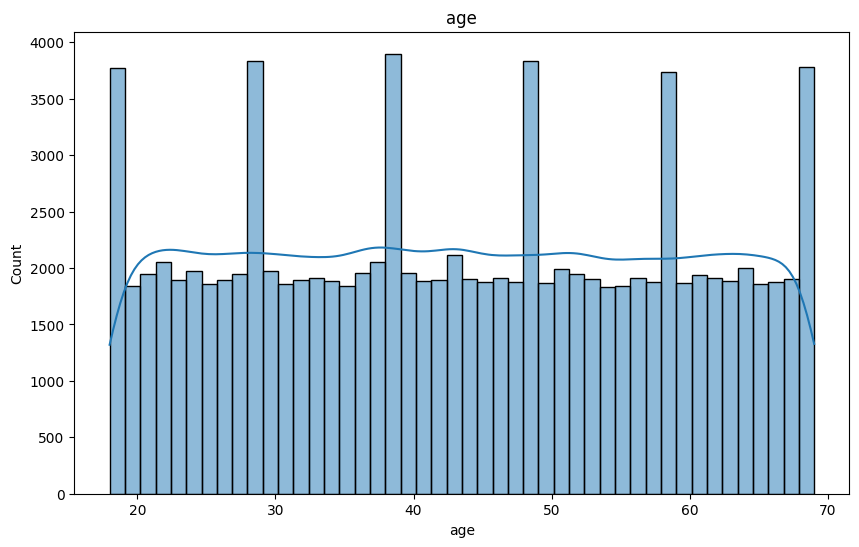

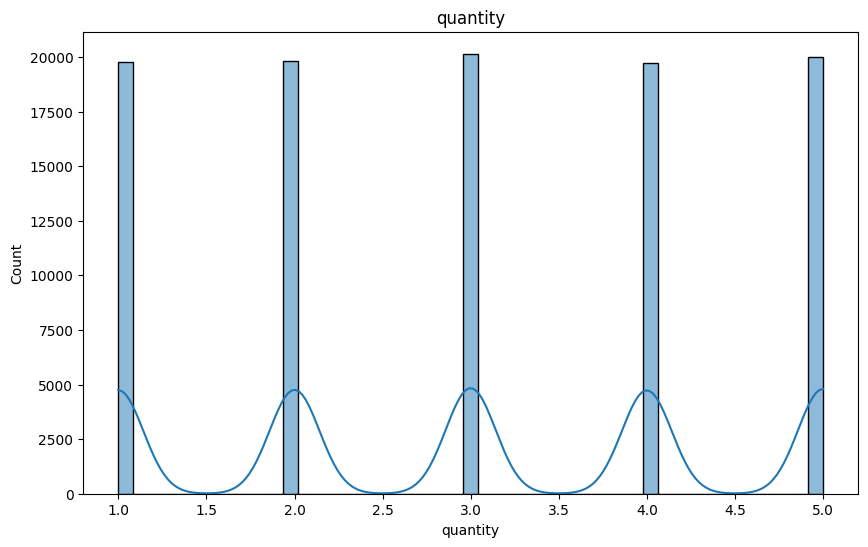

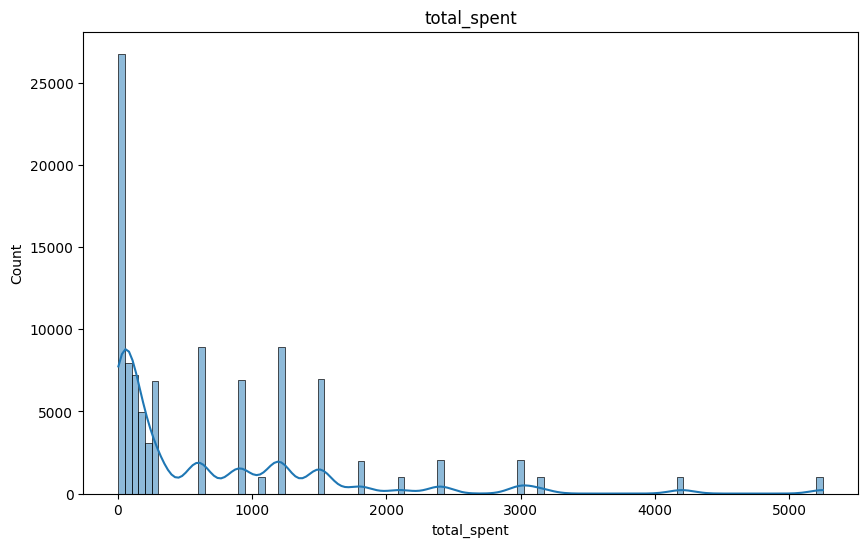

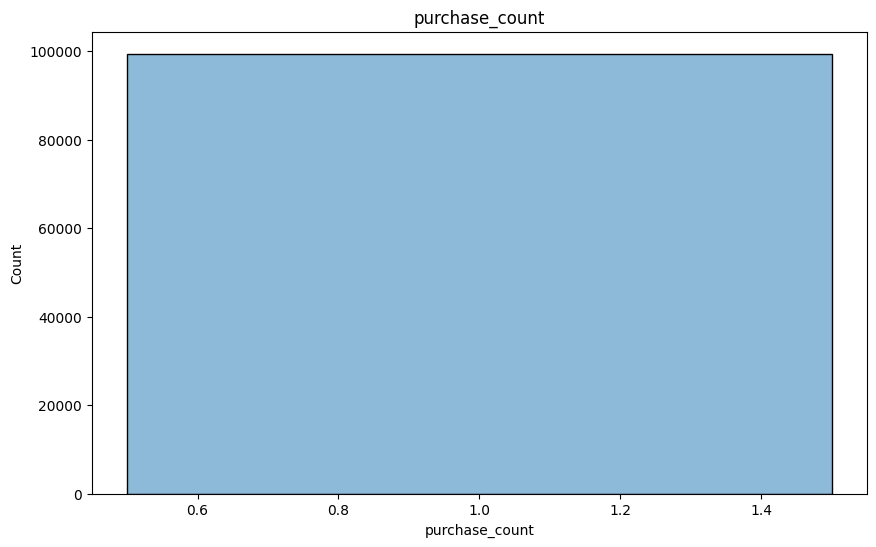

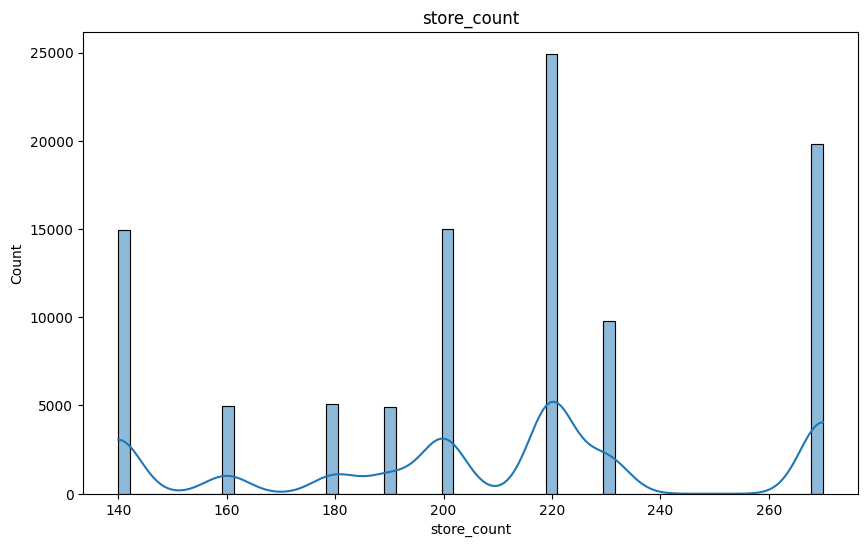

In [46]:
for col in eda_col.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(eda_col[col], kde=True)
    plt.title(col)
    plt.show()

<Axes: xlabel='total_spent', ylabel='purchase_count'>

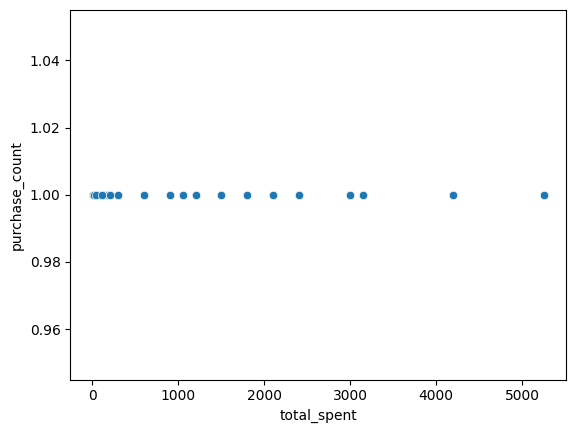

In [47]:
sns.scatterplot(x='total_spent', y='purchase_count', data=eda_col)

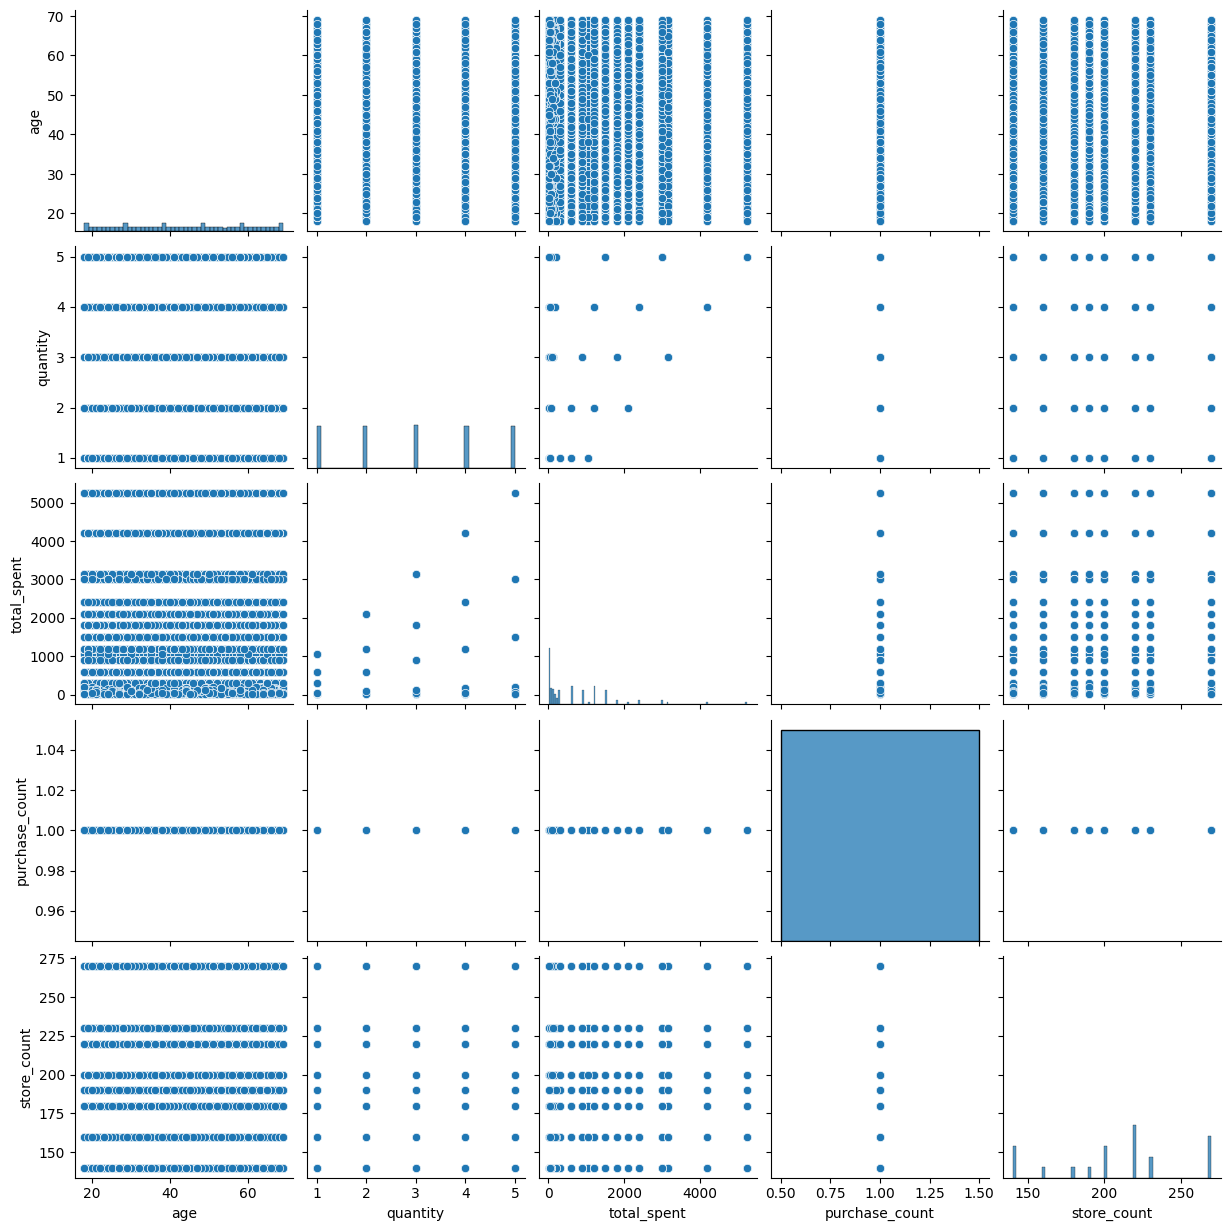

In [48]:
sns.pairplot(eda_col)

<Axes: xlabel='total_spent', ylabel='quantity'>

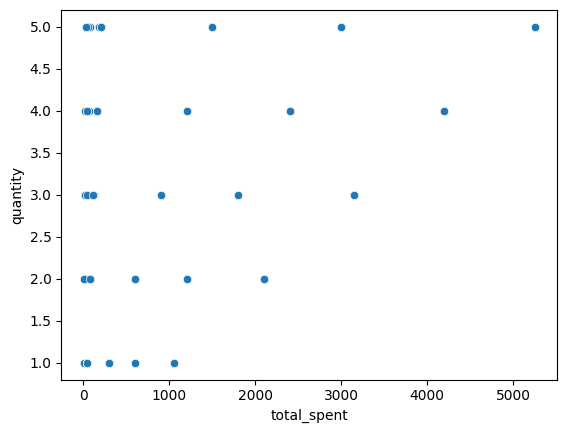

In [49]:
sns.scatterplot(
    x='total_spent',
    y='quantity',
    data=eda_col
)

##**Drop weak features**

In [50]:
final_df=df[['age', 'total_spent', 'store_count']]

In [51]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          99457 non-null  float64
 1   total_spent  99457 non-null  float64
 2   store_count  99457 non-null  float64
dtypes: float64(3)
memory usage: 2.3 MB


## **Handle Skewness**

In [52]:
final_df.loc[:, 'total_spent'] = np.log1p(final_df['total_spent'])

# **Scaling**

In [55]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(final_df)

# **Model Building**

## **ELbow method to Find K**

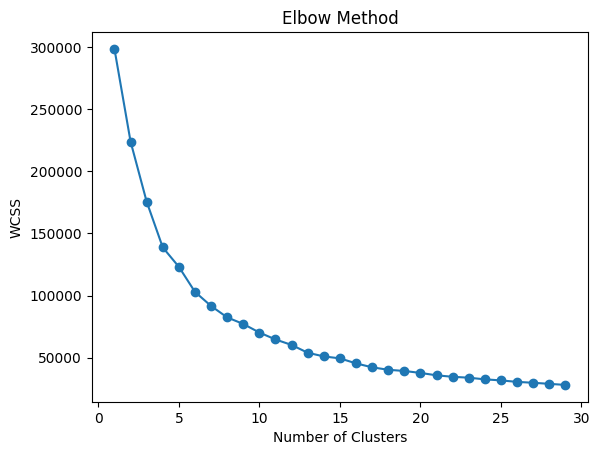

In [63]:


wcss = []

for i in range(1,30):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,30), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

## Train model

In [68]:
kmeans = KMeans(n_clusters=3, random_state=42)
final_df['cluster'] = kmeans.fit_predict(scaled_data)

## **Visulaization of clusters**

<Axes: xlabel='total_spent', ylabel='age'>

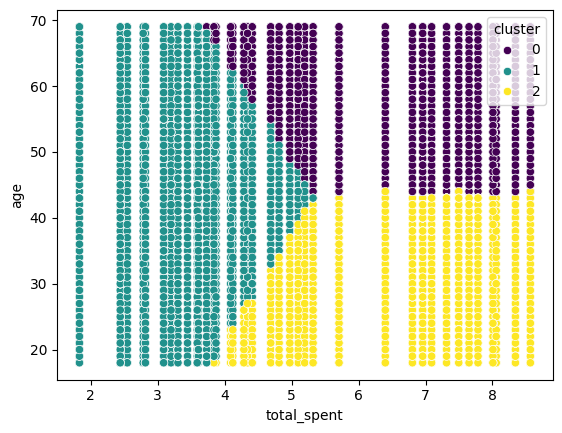

In [69]:
import seaborn as sns

sns.scatterplot(
    x=final_df['total_spent'],
    y=final_df['age'],
    hue=final_df['cluster'],
    palette='viridis'
)

In [70]:
final_df.groupby('cluster').mean()

,age,total_spent,store_count
cluster,,,
0,57.384295,6.439549,210.000000
1,43.242106,3.379075,209.395888
2,29.806499,6.469629,208.748695


## Silheaote Score

In [71]:
from sklearn.metrics import silhouette_score

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.24572623734300908
K=3, Silhouette Score=0.2506500146700234
K=4, Silhouette Score=0.2732075732194714
K=5, Silhouette Score=0.2622046826729748
K=6, Silhouette Score=0.28139104074968835


## Comparing K=3 and K=6

In [72]:
# K = 3
kmeans_3 = KMeans(n_clusters=3, random_state=42)
final_df['cluster_3'] = kmeans_3.fit_predict(scaled_data)

# K = 6
kmeans_6 = KMeans(n_clusters=6, random_state=42)
final_df['cluster_6'] = kmeans_6.fit_predict(scaled_data)

In [73]:
final_df.groupby('cluster_3').mean()

,age,total_spent,store_count,cluster,cluster_6
cluster_3,,,,,
0,57.384295,6.439549,210.000000,0.0,3.214339
1,43.242106,3.379075,209.395888,1.0,0.986591
2,29.806499,6.469629,208.748695,2.0,3.646569


In [74]:
final_df.groupby('cluster_6').mean()

,age,total_spent,store_count,cluster,cluster_3
cluster_6,,,,,
0,56.787391,3.578494,190.380947,0.769292,0.769292
1,30.693183,3.675710,226.397907,1.238755,1.238755
2,32.843259,5.584527,149.404459,1.523118,1.523118
3,55.654599,5.329547,261.073024,0.392158,0.392158
4,56.855804,6.946625,196.116081,0.067838,0.067838
5,30.458396,6.912834,228.666186,1.930839,1.930839


Customer segmentation revealed three key groups: low-value customers, high-value older customers, and young high-spending customers, indicating different behavioral patterns across age groups